<a href="https://colab.research.google.com/github/Heet06/MLUP001/blob/main/Week-4/Data_Visualization_using_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Toyota Car Data Visualization

This Notebook goes hands-on with choosing and creating different plots for the Toyota dataset.

- It utilizes matplotlib and seaborn

- It covers all these plots:
  
  - Bar Chart
  - Line Plot
  - Scatter Plot
  - Box Plot
  - Pie Chart
  - Heatmap
  - Area Chart
  - Pair Plot

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")

#### Load Data
We load Toyota.csv with special characters as NaN and drop missing values.

In [ ]:
df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/datasets/Toyota.csv", index_col=0, na_values=["??", "????"])
df.dropna(inplace=True)
df.head()

,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,13500,23.0,46986.0,Diesel,90.0,1.0,0,2000,three,1165
1,13750,23.0,72937.0,Diesel,90.0,1.0,0,2000,3,1165
3,14950,26.0,48000.0,Diesel,90.0,0.0,0,2000,3,1165
4,13750,30.0,38500.0,Diesel,90.0,0.0,0,2000,3,1170
5,12950,32.0,61000.0,Diesel,90.0,0.0,0,2000,3,1170


#### Data Overview

Quick check of structure and summary statistics

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Price      1096 non-null   int64  
 1   Age        1096 non-null   float64
 2   KM         1096 non-null   float64
 3   FuelType   1096 non-null   object 
 4   HP         1096 non-null   float64
 5   MetColor   1096 non-null   float64
 6   Automatic  1096 non-null   int64  
 7   CC         1096 non-null   int64  
 8   Doors      1096 non-null   object 
 9   Weight     1096 non-null   int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 94.2+ KB


- Doors column should be interger or categorical.

In [ ]:
df['Doors'].unique()

array(['three', '3', '5', '4', 'four', 'five', '2'], dtype=object)

In [ ]:
df['Doors'] = df['Doors'].replace(
    {'three': 3, 'four': 4, 'five': 5}, regex=True
).astype(int)

In [ ]:
print(df['MetColor'].unique())
print(df['Automatic'].unique())

[1. 0.]
[0 1]


In [ ]:
df['MetColor'] = df['MetColor'].astype('str')
df['Automatic'] = df['Automatic'].astype('str')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Price      1096 non-null   int64  
 1   Age        1096 non-null   float64
 2   KM         1096 non-null   float64
 3   FuelType   1096 non-null   object 
 4   HP         1096 non-null   float64
 5   MetColor   1096 non-null   object 
 6   Automatic  1096 non-null   object 
 7   CC         1096 non-null   int64  
 8   Doors      1096 non-null   int64  
 9   Weight     1096 non-null   int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 94.2+ KB


In [ ]:
df.describe()

,Price,Age,KM,HP,CC,Doors,Weight
count,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000
mean,10735.937044,55.661496,69268.826642,101.806569,1568.863139,4.062044,1073.416971
std,3636.716945,18.699777,38070.667467,15.034116,184.386960,0.956488,51.812821
min,4350.000000,1.000000,1.000000,69.000000,1300.000000,2.000000,1000.000000
25%,8450.000000,43.000000,43590.500000,90.000000,1400.000000,3.000000,1045.000000
50%,9900.000000,60.000000,63393.500000,110.000000,1600.000000,4.000000,1070.000000
75%,11950.000000,70.000000,88031.750000,110.000000,1600.000000,5.000000,1090.000000
max,31275.000000,80.000000,243000.000000,192.000000,2000.000000,5.000000,1615.000000


#### Understanding Variable Types in Our Dataset

**Categorical Variables**
- Describle categories or groups
- Examples:
  - FuelType (Petrol, Diesel, CNG)
  - Automatic (0/1)
  - Doors (can be treated as categorical)

- Best Visualizations:
  - Bar Plots
  - Count Plots
  - Pie Charts
  - Grouped boxplots

---
**Numerical Values**
- Continuous or discrete numbers
- Examples:
  - Age (Months)
  - Price (Euros)
  - KM (Kilometers)
  - HP (Horse Power)

- Best Visualizations:
  - Scatter Plots
  - Line Plots
  - Histograms
  - Boxplots
  - Area charts
  - Heatmaps
  - Pairplots

#### Matplotlib Visualization

##### Scatter Plot
**What is it?**
- Shows individual data points on X and Y axis.

**When/Where to use?**
- For visualizing correlations between two numerical variables.

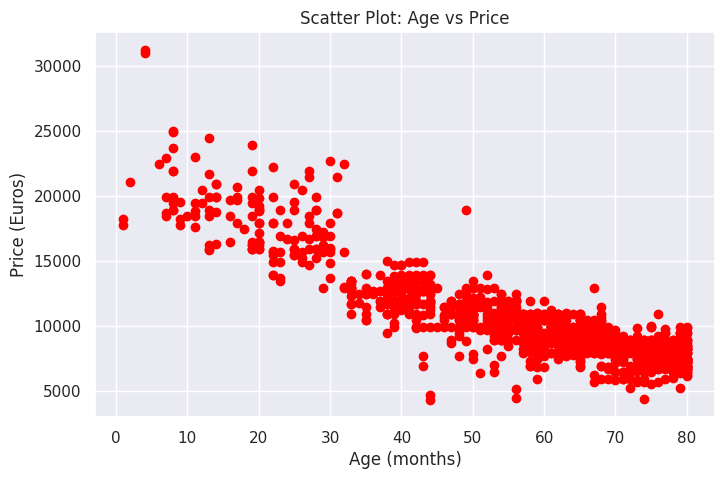

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['Age'], df['Price'], color='red')
plt.title('Scatter Plot: Age vs Price')
plt.xlabel('Age (months)')
plt.ylabel('Price (Euros)')
plt.show()

**Inference**
- The scatter plot shows a clear negative relationship between Age and Price. As the car's age increases. its price drops significantly.

##### Line Plot

**What is it?**
- Connects data points with lines to show trends over an ordered axis.

**When/Where to use?**
- Best for time series or sequential data.

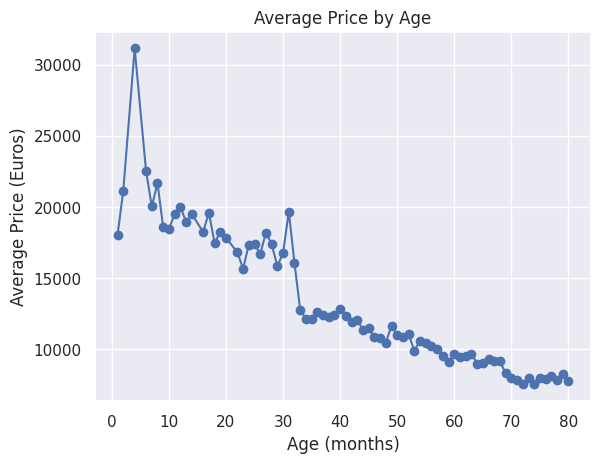

In [ ]:
age_price = df.groupby('Age')['Price'].mean().sort_index()
age_price.plot(kind="line", marker="o")
plt.title("Average Price by Age")
plt.xlabel("Age (months)")
plt.ylabel("Average Price (Euros)")
plt.show()

**Inference**
- The line plot of average Price by Age reveals a consistent downward trend. If emphasizes that as vehicle ages, their average market value declines, confirming the expected depreciation pattern in the dataset/

##### Bar Plot

**What is it?**
- Compares values across categories

**When/Where to use?**
- Best for categorical variables

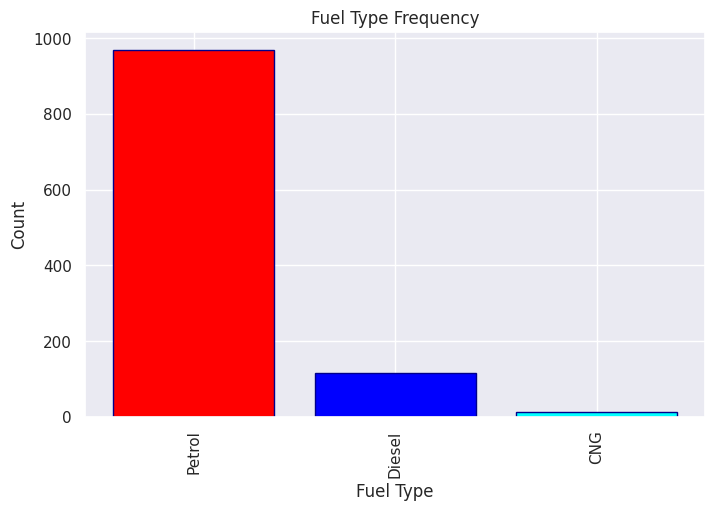

In [ ]:
fuel_counts = df['FuelType'].value_counts()
index = np.arange(len(fuel_counts))
plt.figure(figsize=(8, 5))
plt.bar(index, fuel_counts, color=['red', 'blue', 'cyan'], edgecolor='darkblue')
plt.title("Fuel Type Frequency")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.xticks(index, fuel_counts.index, rotation=90)
plt.show()

**Inference**
- The bar plot shows Petrol cars dominate the dataset, followed by Diesel and very few CNG vehicles. This distribution highlights the preference for Petrol vehicles in the sample

##### Pie Chart

**What is it?**
- Shows part of a whole

**When/Where to use?**
- Good for showing category proportions.

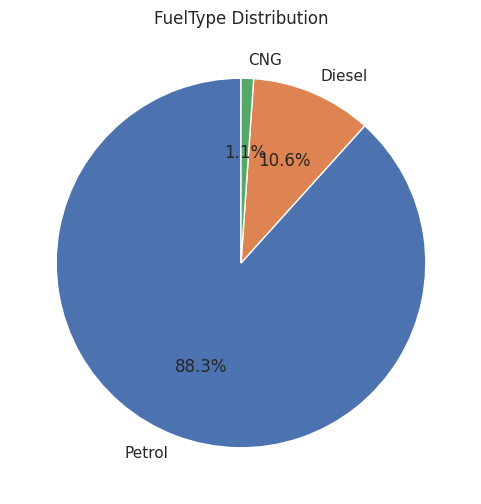

In [ ]:
fuel_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90, figsize=(6,6))
plt.title('FuelType Distribution')
plt.ylabel('')
plt.show()

**Inference**
- Petrol cars dominate the dataset, making up 88.3% of all entries.
- Diesel vehicles account for 10.6% a much smaller share.
- CNG vehicles are extremely rare, representing only 1.1%.

##### Histogram

**What is it?**
- Shows distribution of a single numerical variable.

**When/Where to use?**
- To see, spread, skew,outliers.

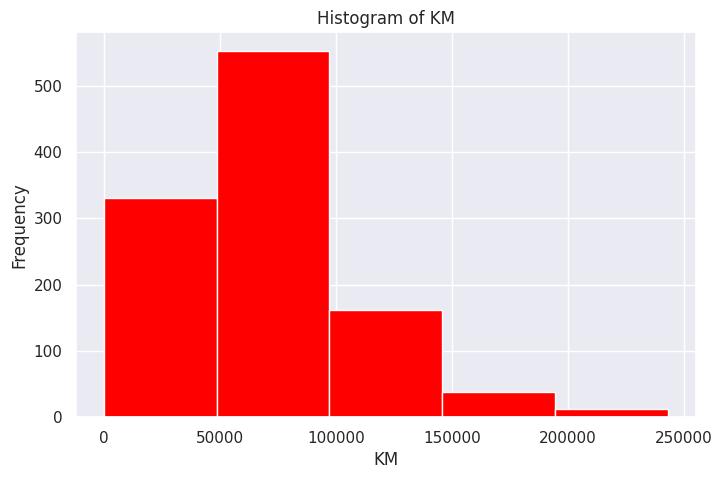

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['KM'], bins=5, color='red', edgecolor='white')
plt.title('Histogram of KM')
plt.xlabel('KM')
plt.ylabel('Frequency')
plt.show()

**Inference**
- Most vehicles have low to moderate KM values.
- The largest number of cars fall in the 50,000-100,000 KM range.